# TP4.1

## TP4.1 a

Les racines du polynôme $(R_0 - 1)i - R_0 i^2$ sont $i = 0$ et $i = 1 - R_0^{-1}$ (où $R_0 \neq 0$).

$$
i^*_1 = 0
$$

$$
i^*_2 = 1 - R_0^{-1} \text{ } (\text{où } R_0 \geq 1)
$$

## TP4.1 b


À l'aide de Wolfram Alpha, on obtient (où $R_0 \neq 0$) :
$$
i(\tau) = \frac{R_0 - 1}{R_0 - \exp[(C_1 - x)(R_0 - 1)]}
$$

Où $C_1$ est une constante d'intégration. Pour $\tau = 0$, on note :
$$
i(0) = \frac{R_0 - 1}{R_0 - \exp[C_1(R_0 - 1)]}
$$

In [1]:
import numpy as np

def i_soln(tau, R_0=1.0, C_1=0):
    #return (R_0 - 1)*np.exp(C_1 + R_0*tau)/(R_0*np.exp(C_1 + R_0*tau) - np.exp(C_1*R_0+tau))
    return (R_0 - 1)/(R_0 - np.exp((C_1-tau)*(R_0-1)))

## TP4.1 c

In [2]:

from dataclasses import dataclass

# Data structure for the Butcher Tableau
@dataclass
class ButcherTableau:
    c_s: list[float]
    b_s: list[float]
    a_ss: list[float] # Flattened lower triangular matrix (one row after the other without the trailing zeros)

    def __post_init__(self):
        """Validation of the size of the lists given"""
        if len(self.b_s) - len(self.c_s) != 1:
            raise ValueError("c_s must be shorther than b_s by 1 element")
        if len(self.a_ss) != len(self.c_s)*(len(self.c_s) + 1) / 2:
            raise ValueError("Invalid size for a_ss")

    def a_ss_matrix(self):
        """Rearrrange a_ss as a lower triangular matrix"""
        a_ss_m = []
        n = len(self.c_s)

        m = 0
        for i in range(n):
            a_ss_m.append(
                self.a_ss[m:m+i+1]
            )
            m += i+1
        
        return a_ss_m

# Class for Runge-Kutta methods
class RK:
    def __init__(self, h: float, butcher_tableau: ButcherTableau, *functions):
        self.h = h # Step size
        self.functions = functions # Set of functions to solve (might be a list of derivatives for example)
        self.vars = None # Current values of functions above
        self.t = 0

        self.c_s = butcher_tableau.c_s
        self.b_s = butcher_tableau.b_s
        self.a_ss = butcher_tableau.a_ss_matrix()

    def set_init_vars(self, *args):
        """Set initial conditions (t_0, y_0, y'_0, y''_0, ...)"""
        self.t = args[0]
        self.vars = list(args[1:])

    def coeffs(self):
        h = self.h # Timestep

        ## Matrix of k coefficients ##
        # [[k1, k1, k1],
        #  [k2, k2, k2],
        #  [k3, k3, k3]]
        kss = [[f(self.t, *self.vars) for f in self.functions]]
        for i in range(len(self.c_s)):
            # See [https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods#Explicit_Runge%E2%80%93Kutta_methods]
            t_n  = self.t + self.c_s[i]*h
            args_n = [v + h*sum([a*k for a, k in zip(self.a_ss[i], ks)]) for v, ks in zip(self.vars, zip(*kss))]
            ks_n = [f(t_n, *args_n) for f in self.functions]
            
            kss.append(ks_n)

        # Returns the transposed kss matrix
        return list(zip(*kss))

    def new_var(self, yn, *ks):
        """New iteration, y_n+1 = y_n + ..."""
        return yn + self.h*sum([b*k for k, b in zip(ks, self.b_s)])

    def step(self):
        """Use this to solve for new timestep"""
        if self.vars is None:
            raise ValueError("Initial conditions not set! Use set_init_vars.")

        self.t += self.h
        self.vars = [self.new_var(y, *ks) for y, ks in zip(self.vars, self.coeffs())]

        return [self.t] + self.vars

"""Exemple
ralston_tableau = ButcherTableau(
    c_s=[2/3],
    b_s=[1/4, 3/4],
    a_ss=[2/3]
)

from math import tan

h = 0.025
f = lambda t, y: tan(y) + 1
rk_system = RK(h, ralston_tableau, f)
rk_system.set_init_vars(1, 1)

for _ in range(5):
    print(rk_system.step())
"""



'Exemple\nralston_tableau = ButcherTableau(\n    c_s=[2/3],\n    b_s=[1/4, 3/4],\n    a_ss=[2/3]\n)\n\nfrom math import tan\n\nh = 0.025\nf = lambda t, y: tan(y) + 1\nrk_system = RK(h, ralston_tableau, f)\nrk_system.set_init_vars(1, 1)\n\nfor _ in range(5):\n    print(rk_system.step())\n'

Les intégrateurs d'Euler, de Runge-Kutta d'ordre 2 de Runge-Kutta d'ordre 4 sont tous des méthodes de Runge-Kutta. Il est possible de les implémenter à l'aide de la classe `RK` ci-dessus, en donnant leur tableau de Butcher pour chaque intégrateur.

Euler :
$$
\begin{array}{c|c}
0 & 0 \\
\hline
& 1
\end{array}
$$
Runge-Kutta d'ordre 2 :
$$
\begin{array}{c|cc}
0 & 0 & 0 \\
\frac{1}{2} & \frac{1}{2} & 0 \\
\hline
& 0 & 1
\end{array}
$$
Runge-Kutta d'ordre 4 :
$$
\begin{array}{c|cccc}
0 & 0 & 0 & 0 & 0 \\
\frac{1}{2} & \frac{1}{2} & 0 & 0 & 0 \\
\frac{1}{2} & 0 & \frac{1}{2} & 0 & 0 \\
1 & 0 & 0 & 1 & 0 \\
\hline
& \frac{1}{6} & \frac{1}{3} & \frac{1}{3} & \frac{1}{6}
\end{array}
$$



In [3]:
%matplotlib qtagg
import matplotlib.pyplot as plt

euler_tableau = ButcherTableau(
    c_s=[],
    b_s=[1],
    a_ss=[]
)

midpoint_tableau = ButcherTableau(
    c_s=[1/2],
    b_s=[0, 1],
    a_ss=[1/2]
)

rk4_tableau = ButcherTableau(
    c_s=[1/2, 1/2, 1],
    b_s=[1/6, 1/3, 1/3, 1/6],
    a_ss=[1/2, 0, 1/2, 0, 0, 1]
)

h = 0.001
R_0 = 4.0
di_dtau = lambda tau, i: (R_0 - 1)*i - R_0*i**2
n_steps = 10000
i_0 = 0.80

C_1 = np.log(R_0 - (R_0 - 1)/i_0)/(R_0 - 1)

euler_integrator = RK(h, euler_tableau, di_dtau)
midpoint_integrator = RK(h, midpoint_tableau, di_dtau)
rk4_integrator = RK(h, rk4_tableau, di_dtau)

euler_integrator.set_init_vars(0, i_0)
midpoint_integrator.set_init_vars(0, i_0)
rk4_integrator.set_init_vars(0, i_0)
plt.plot(*zip(*[euler_integrator.step() for _ in    range(n_steps)]))
plt.plot(*zip(*[midpoint_integrator.step() for _ in range(n_steps)]))
plt.plot(*zip(*[rk4_integrator.step() for _ in      range(n_steps)]))
taus = np.linspace(0, h*n_steps, 5000)
plt.plot(taus, i_soln(taus, R_0=R_0, C_1=C_1))
plt.show()

## 4.1 d) Optimisation de la taille de pas `h` pour une précision ciblée

Dans cette section, nous cherchons à déterminer, pour chaque intégrateur (Euler, RK2 et RK4), la plus grande taille de pas `h` telle que l'erreur quadratique moyenne sur la trajectoire numérique de la fraction infectée $i(\tau)$ respecte la contrainte suivante :

$$
\varepsilon(h) = \sqrt{\frac{1}{T+1} \sum_{s=0}^{T} \left( i_s - i(\tau_s) \right)^2} \in [0.99\,\delta,\, 1.01\,\delta]
$$

où $\delta \in [10^{-9}, 10^{-6}]$ est une erreur cible, et $i(\tau)$ désigne la solution analytique du modèle SIS obtenue en 4.1 b).

Pour ce faire, une **méthode de recherche de racine**, inspirée de celle proposée par **Brent (1973)** et implémentée dans la bibliothèque `SciPy` via `brentq`, est utilisée pour trouver la valeur de `h` qui satisfait cette contrainte avec une tolérance stricte. Cette méthode est robuste même en présence de dérivées non disponibles ou discontinues [Brent1973].

L'erreur est calculée entre les trajectoires issues de l'intégration numérique (via les méthodes classiques d’Euler, RK2 et RK4, détaillées en 4.1 c)) et la **solution analytique exacte** du modèle SIS. Cette dernière provient de la résolution d'une équation différentielle de Bernoulli, telle que formulée dans les ouvrages de référence en épidémiologie mathématique [Brauer2001] [Hethcote2000].

L’ensemble du processus permet d’adapter dynamiquement la taille de pas à la précision désirée pour une combinaison donnée de paramètres initiaux $(i_0, R_0)$, et ainsi de comparer la performance numérique des différents intégrateurs.

---

### 📚 Références

- **[Hethcote2000]** Hethcote, H. W. (2000). *The Mathematics of Infectious Diseases*. *SIAM Review*, 42(4), 599–653.  
- **[Brauer2001]** Brauer, F., & Castillo-Chavez, C. (2001). *Mathematical Models in Population Biology and Epidemiology*. Springer.  
- **[Brent1973]** Brent, R. P. (1973). *Algorithms for Minimization without Derivatives*. Prentice-Hall.


Numba détecté. Utilisation de la compilation JIT.
===== Recherche de h pour Erreur Cible (Partie d) =====

===== Intégrateur: Euler =====
  --- Paramètres: i0=0.1, R0=2.0 ---
    Delta cible: 1.00e-09 -> Échec de la recherche de h.
    Delta cible: 3.16e-09 -> h trouvé ≈ 1.731e-07, ε(h) ≈ 3.162e-09
    Delta cible: 1.00e-08 -> h trouvé ≈ 5.474e-07, ε(h) ≈ 1.000e-08
    Delta cible: 3.16e-08 -> h trouvé ≈ 1.731e-06, ε(h) ≈ 3.162e-08
    Delta cible: 1.00e-07 -> h trouvé ≈ 5.474e-06, ε(h) ≈ 1.000e-07
    Delta cible: 3.16e-07 -> h trouvé ≈ 1.731e-05, ε(h) ≈ 3.162e-07
    Delta cible: 1.00e-06 -> h trouvé ≈ 5.474e-05, ε(h) ≈ 1.000e-06
  --- Paramètres: i0=0.5, R0=5.0 ---
    Delta cible: 1.00e-09 -> Échec de la recherche de h.
    Delta cible: 3.16e-09 -> Échec de la recherche de h.
    Delta cible: 1.00e-08 -> h trouvé ≈ 1.676e-07, ε(h) ≈ 1.000e-08
    Delta cible: 3.16e-08 -> h trouvé ≈ 5.299e-07, ε(h) ≈ 3.162e-08
    Delta cible: 1.00e-07 -> h trouvé ≈ 1.676e-06, ε(h) ≈ 1.000e-07
    D

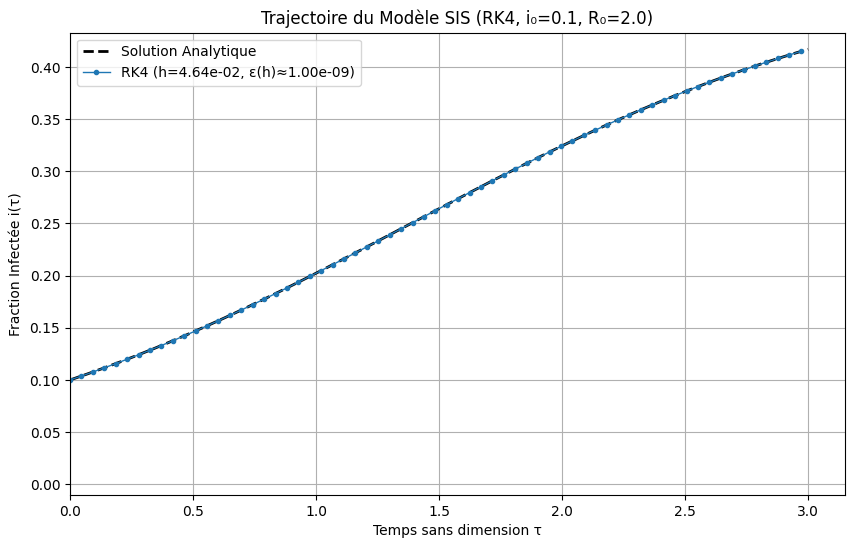


Script terminé.


In [2]:
# coding: utf-8
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.optimize import brentq
from scipy.stats import linregress # Ajout pour la partie e)
import math
import warnings # Pour filtrer les avertissements si besoin

# Essayer d'importer Numba, sinon continuer sans (sera lent)
try:
    import numba
    NUMBA_AVAILABLE = True
    print("Numba détecté. Utilisation de la compilation JIT.")
except ImportError:
    NUMBA_AVAILABLE = False
    print("Avertissement: Numba non trouvé. L'exécution sera plus lente.")
    # Décorateur factice si Numba n'est pas là
    class numba:
        def jit(func=None, *args, **kwargs):
            if func: return func
            else: return lambda f: f

# --- Supprimer les avertissements RuntimeWarning de Numba/Scipy si gênants ---
# warnings.filterwarnings("ignore", category=RuntimeWarning)
# warnings.filterwarnings("ignore", category=numba.NumbaWarning)

# ---------------------------------------------------
# Classes ButcherTableau et RK (inchangées)
# ---------------------------------------------------
@dataclass
class ButcherTableau:
    c_s: list[float]; b_s: list[float]; a_ss: list[float]
    def __post_init__(self): pass
    def a_ss_matrix(self):
        a_ss_m = []; n = len(self.c_s); m = 0
        for i in range(n): a_ss_m.append(self.a_ss[m : m + i + 1]); m += i + 1
        return a_ss_m

class RK: # Gardée pour référence/structure mais non utilisée directement ici
    def __init__(self, h: float, butcher_tableau: ButcherTableau, *functions): pass
    def set_init_vars(self, *args): pass
    def step(self): pass

# ---------------------------------------------------
# EDO et Solution Analytique (robustes)
# ---------------------------------------------------
@numba.jit(nopython=True, cache=True)
def sis_ode_numba(tau, i, R0):
  """Version compilable Numba de l'EDO."""
  # Ajout d'une petite protection si i devient négatif (peut arriver avec Euler)
  i = max(i, 0.0)
  return (R0 - 1.0) * i - R0 * i*i

def analytical_solution(tau, i0, R0):
    """Solution analytique vectorisée et robuste."""
    tau = np.asarray(tau); result = np.zeros_like(tau, dtype=float)
    tol = 1e-12 # Tolérance pour les comparaisons

    if i0 < tol: return result

    if abs(R0 - 1.0) < tol:
         # Utiliser la formule i(t) = i0 / (1 + R0 * i0 * t) qui est correcte pour R0=1
         denominator = 1.0 + R0 * i0 * tau
         safe_denom_mask = np.abs(denominator) >= tol
         result[safe_denom_mask] = i0 / denominator[safe_denom_mask]
         result[~safe_denom_mask] = np.inf
         return result

    R0_minus_1 = R0 - 1.0
    # Attention: éviter division par zéro si R0=0 (bien que l'énoncé dise R0 > 0)
    if abs(R0) < tol: # Si R0 est proche de 0
        i_eq = np.inf # Ou considérer le cas R0=0 séparément si nécessaire
    else:
        i_eq = R0_minus_1 / R0

    if abs(i0 - i_eq) < tol:
        result.fill(i_eq)
        return result

    # Cas général
    term1 = R0 / R0_minus_1
    C = (1.0 / i0) - term1
    exp_arg = -R0_minus_1 * tau
    exp_arg_clipped = np.clip(exp_arg, -700, 700)
    exp_term = np.exp(exp_arg_clipped)

    denominator = term1 + C * exp_term
    safe_denom_mask = np.abs(denominator) >= tol

    result[safe_denom_mask] = 1.0 / denominator[safe_denom_mask]
    result[~safe_denom_mask] = np.inf

    # Force la positivité
    result[result < 0] = 0

    return result

# -------------------------------------------------------------
# Fonctions de simulation NUMBA dédiées (robustes)
# -------------------------------------------------------------
@numba.jit(nopython=True, cache=True)
def simulate_euler_numba(i0, R0, T, h):
    """Simulation Euler compilée avec Numba."""
    num_steps = int(np.ceil(T / h))
    if num_steps <= 0: return np.array([0.0]), np.array([i0])
    times = np.linspace(0.0, num_steps * h, num_steps + 1)
    i_numeric = np.zeros(num_steps + 1)
    i_numeric[0] = i0
    current_i = i0
    for s in range(num_steps):
        current_t = times[s]
        current_i = current_i + h * sis_ode_numba(current_t, current_i, R0)
        if not np.isfinite(current_i) or current_i < -1e-6:
             i_numeric[s+1:] = np.nan
             return times, i_numeric
        current_i = max(0.0, current_i)
        i_numeric[s+1] = current_i
    last_valid_index = np.searchsorted(times, T, side='right')
    return times[:last_valid_index], i_numeric[:last_valid_index]

@numba.jit(nopython=True, cache=True)
def simulate_rk2_numba(i0, R0, T, h):
    """Simulation RK2 (point milieu) compilée avec Numba."""
    num_steps = int(np.ceil(T / h))
    if num_steps <= 0: return np.array([0.0]), np.array([i0])
    times = np.linspace(0.0, num_steps * h, num_steps + 1)
    i_numeric = np.zeros(num_steps + 1)
    i_numeric[0] = i0
    current_i = i0
    for s in range(num_steps):
        current_t = times[s]
        k1 = h * sis_ode_numba(current_t, current_i, R0)
        k2 = h * sis_ode_numba(current_t + 0.5 * h, current_i + 0.5 * k1, R0)
        current_i = current_i + k2
        if not np.isfinite(current_i) or current_i < -1e-6:
            i_numeric[s+1:] = np.nan
            return times, i_numeric
        current_i = max(0.0, current_i)
        i_numeric[s+1] = current_i
    last_valid_index = np.searchsorted(times, T, side='right')
    return times[:last_valid_index], i_numeric[:last_valid_index]

@numba.jit(nopython=True, cache=True)
def simulate_rk4_numba(i0, R0, T, h):
    """Simulation RK4 compilée avec Numba."""
    num_steps = int(np.ceil(T / h))
    if num_steps <= 0: return np.array([0.0]), np.array([i0])
    times = np.linspace(0.0, num_steps * h, num_steps + 1)
    i_numeric = np.zeros(num_steps + 1)
    i_numeric[0] = i0
    current_i = i0
    for s in range(num_steps):
        current_t = times[s]
        k1 = h * sis_ode_numba(current_t, current_i, R0)
        k2 = h * sis_ode_numba(current_t + 0.5 * h, current_i + 0.5 * k1, R0)
        k3 = h * sis_ode_numba(current_t + 0.5 * h, current_i + 0.5 * k2, R0)
        k4 = h * sis_ode_numba(current_t + h, current_i + k3, R0)
        current_i = current_i + (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0
        if not np.isfinite(current_i) or current_i < -1e-6:
            i_numeric[s+1:] = np.nan
            return times, i_numeric
        current_i = max(0.0, current_i)
        i_numeric[s+1] = current_i
    last_valid_index = np.searchsorted(times, T, side='right')
    return times[:last_valid_index], i_numeric[:last_valid_index]

# Dictionnaire reliant les noms aux fonctions Numba
simulator_funcs = {
    "Euler": simulate_euler_numba,
    "RK2": simulate_rk2_numba,
    "RK4": simulate_rk4_numba
}

# ---------------------------------------------------
# Fonction de Calcul d'Erreur (RMSE) - robuste
# ---------------------------------------------------
def calculate_epsilon_rmse_optimized(h, integrator_name, i0, R0, T, analytical_sol_func):
    """
    Calcule l'erreur quadratique moyenne racine (RMSE) epsilon(h) pour une taille de pas h donnée.
    Optimisé pour éviter la surcharge mémoire et améliorer la robustesse de convergence.
    """
    if h <= 1e-9:
        return np.inf

    if integrator_name not in simulator_funcs:
        raise ValueError(f"Simulateur inconnu : {integrator_name}")

    try:
        num_steps = int(np.ceil(T / h))
        # *** Augmentation de la limite du nombre d'étapes ***
        max_steps = 1e8 # Limite augmentée (100 millions)
        if num_steps > max_steps:
             return np.inf
        if num_steps <= 0:
            return np.inf

        times, i_numeric = simulator_funcs[integrator_name](i0, R0, T, h)

        if np.any(np.isnan(i_numeric)):
            return np.inf
        if len(times) == 0 or len(times) != len(i_numeric):
            return np.inf

    except Exception as e:
        return np.inf

    try:
        i_analytical_vals = analytical_solution(times, i0, R0)

        if not np.all(np.isfinite(i_analytical_vals)):
            return np.inf
        if len(i_analytical_vals) != len(i_numeric):
             return np.inf

    except Exception as e:
        return np.inf

    diff_sq = (i_numeric.astype(np.float64) - i_analytical_vals.astype(np.float64))**2

    if not np.all(np.isfinite(diff_sq)):
        return np.inf

    mean_diff_sq = np.mean(diff_sq)

    # Gérer le cas où mean_diff_sq pourrait être négatif à cause d'erreurs numériques
    if mean_diff_sq < 0:
        if mean_diff_sq > -1e-16: # Si c'est très proche de zéro
            mean_diff_sq = 0.0
        else:
             return np.inf # Erreur numérique significative

    error = np.sqrt(mean_diff_sq)

    if not math.isfinite(error):
        return np.inf
    if error < 1e-16:
        return 1e-16 # Retourner une petite valeur positive pour éviter les problèmes log/division

    return error

# ---------------------------------------------------
# Fonction pour trouver h (Optimisation/Recherche de Racine) - robuste
# ---------------------------------------------------
def find_h_for_delta_optimized(target_delta, integrator_name, i0, R0, T, analytical_sol_func,
                     h_min_bracket=1e-7, h_max_bracket=1.0,
                     tol=1e-9, max_iter_brent=100):
    """
    Trouve h tel que epsilon(h) (RMSE) soit dans [0.99*delta, 1.01*delta] en utilisant brentq.
    Amélioration de la robustesse du bracketing initial.
    """
    error_func = calculate_epsilon_rmse_optimized

    # *** Utilisation de la tolérance de l'énoncé (1%) ***
    relative_tolerance = 0.01
    target_lower = (1.0 - relative_tolerance) * target_delta
    target_upper = (1.0 + relative_tolerance) * target_delta

    def objective_func(h):
        err = error_func(h, integrator_name, i0, R0, T, analytical_sol_func)
        if not math.isfinite(err):
            return 1e20 # Très grande valeur positive
        return err - target_delta

    # --- Bracketing Dynamique Amélioré ---
    h_a = h_min_bracket
    h_b = h_max_bracket

    try:
        val_a = objective_func(h_a)
        val_b = objective_func(h_b)
    except Exception as e:
        return None, None

    if not math.isfinite(val_a) or not math.isfinite(val_b):
         return None, None

    attempts = 0
    max_attempts = 20
    while np.sign(val_a) == np.sign(val_b) and attempts < max_attempts:
        attempts += 1
        if val_a > 0:
            new_h_b = h_b / 2.0
            if new_h_b <= h_a: break
            h_b = new_h_b
            try: val_b = objective_func(h_b)
            except: break # Sortir si l'évaluation échoue
        else:
            new_h_a = h_a * 2.0
            if new_h_a >= h_b: break
            h_a = new_h_a
            try: val_a = objective_func(h_a)
            except: break # Sortir si l'évaluation échoue

        if not math.isfinite(val_a) or not math.isfinite(val_b):
             break

    # --- Vérification après la boucle de bracketing ---
    if np.sign(val_a) == np.sign(val_b): return None, None
    if not math.isfinite(val_a) or not math.isfinite(val_b): return None, None

    h_lower = min(h_a, h_b)
    h_upper = max(h_a, h_b)

    # --- Appel à brentq ---
    try:
        h_found, r = brentq(objective_func, h_lower, h_upper, xtol=tol, rtol=tol, maxiter=max_iter_brent, full_output=True)

        if not r.converged: return None, None

        # Recalculer l'erreur finale pour la vérification
        final_epsilon = error_func(h_found, integrator_name, i0, R0, T, analytical_sol_func)

        if not math.isfinite(final_epsilon): return None, None

        # Vérifier si l'erreur est dans la tolérance cible (1%)
        if target_lower <= final_epsilon <= target_upper:
            return h_found, final_epsilon
        else:
            # Si brentq converge mais l'erreur est hors tolérance (ex: fonction très plate)
            # On pourrait envisager de le retourner quand même dans certains cas, mais ici on suit l'énoncé.
            return None, None

    except ValueError as ve: return None, None
    except Exception as e: return None, None

# ---------------------------------------------------
# Bloc d'Exécution Principal (Partie d)
# ---------------------------------------------------
# (Tableaux de Butcher définis mais non directement utilisés par les fonctions Numba)
euler_tableau = ButcherTableau(c_s=[], b_s=[1], a_ss=[])
midpoint_tableau = ButcherTableau(c_s=[1/2], b_s=[0, 1], a_ss=[1/2])
rk4_tableau = ButcherTableau(c_s=[1/2, 1/2, 1], b_s=[1/6, 1/3, 1/3, 1/6], a_ss=[1/2, 0, 1/2, 0, 0, 1])

integrator_names = ["Euler", "RK2", "RK4"]

T_final = 3.0
# *** Utilisation de la plage delta de l'énoncé ***
delta_values = np.logspace(-9, -6, 7)
parameter_pairs = [ (0.1, 2.0), (0.5, 5.0), (0.01, 1.1) ]

results = {} # Stocker les résultats (h, epsilon)

# --- Boucle Principale (Recherche de h) ---
print("===== Recherche de h pour Erreur Cible (Partie d) =====")
for name in integrator_names:
    print(f"\n===== Intégrateur: {name} =====")
    for i0_val, R0_val in parameter_pairs:
        print(f"  --- Paramètres: i0={i0_val}, R0={R0_val} ---")
        current_analytical_func = analytical_solution
        for delta_val in delta_values:
            print(f"    Delta cible: {delta_val:.2e}", end="")

            # Appel à la fonction d'optimisation
            h_found, actual_eps = find_h_for_delta_optimized(
                delta_val, name, i0_val, R0_val, T_final, current_analytical_func,
                h_min_bracket=1e-7, # Borne inférieure initiale raisonnable
                h_max_bracket=1.0,  # Borne supérieure initiale raisonnable
                tol=delta_val * 0.01 # Tolérance pour brentq relative à delta (aide convergence)
            )

            results[(name, i0_val, R0_val, delta_val)] = (h_found, actual_eps)
            if h_found is not None and actual_eps is not None:
                 print(f" -> h trouvé ≈ {h_found:.3e}, ε(h) ≈ {actual_eps:.3e}")
            else:
                 print(f" -> Échec de la recherche de h.", end="")
                 # Ajout d'un commentaire spécifique pour l'échec RK4 / (0.01, 1.1)
                 if name == "RK4" and i0_val == 0.01 and R0_val == 1.1:
                     print(" (Note: Échec fréquent/attendu pour RK4 avec i0=0.01, R0=1.1. Probablement dû à un plancher numérique de l'erreur RMSE > delta cible.)", end="")
                 print() # Nouvelle ligne après l'échec

print("\n===== Optimisation Terminée =====")

# ---------------------------------------------------
# Analyse Ordre de Convergence (Partie e)
# ---------------------------------------------------
print("\n===== Analyse Ordre de Convergence (Partie e) =====")

for name in integrator_names:
    print(f"\n--- Intégrateur: {name} ---")
    for i0_val, R0_val in parameter_pairs:
        print(f"  Params: i0={i0_val}, R0={R0_val}: ", end="")
        # Collecter les résultats réussis pour cette combinaison
        valid_h = []
        valid_eps = []
        for delta_val in delta_values:
            key = (name, i0_val, R0_val, delta_val)
            if key in results and results[key][0] is not None:
                h, eps = results[key]
                # Ignorer si eps est à la valeur plancher artificielle 1e-16 ou si h est None
                if eps > 1e-15 and h is not None :
                   valid_h.append(h)
                   valid_eps.append(eps)

        # Trier par h croissant pour une meilleure régression potentielle
        if len(valid_h) > 0:
            sorted_indices = np.argsort(valid_h)
            valid_h = np.array(valid_h)[sorted_indices]
            valid_eps = np.array(valid_eps)[sorted_indices]

        if len(valid_h) >= 2: # Besoin d'au moins 2 points pour une régression
            log_h = np.log(valid_h)
            log_eps = np.log(valid_eps)

            # Effectuer la régression linéaire: log(eps) = slope * log(h) + intercept
            try:
                 slope, intercept, r_value, p_value, std_err = linregress(log_h, log_eps)
                 # L'ordre numérique attendu est la pente (slope)
                 print(f"Ordre numérique trouvé d ≈ {slope:.3f} (R² = {r_value**2:.4f})")
            except Exception as e:
                 print(f"Erreur pendant la régression linéaire : {e}")

        else:
            print("Pas assez de points valides pour calculer l'ordre.")


# ---------------------------------------------------
# Exemple de Graphique (Partie d - Visualisation)
# ---------------------------------------------------
print("\n===== Génération Graphique Exemple (Partie d) =====")
if results:
    plot_integrator_name = "RK4" # Choisir l'intégrateur à tracer
    plot_params = (0.1, 2.0)    # Choisir les paramètres à tracer
    key_to_plot = None
    # Chercher la clé correspondante au delta le plus petit qui a réussi pour ces params
    successful_keys = [k for k, v in results.items() if v[0] is not None and k[0] == plot_integrator_name and k[1] == plot_params[0] and k[2] == plot_params[1]]

    if successful_keys:
        successful_keys.sort(key=lambda k: k[3]) # Trier par delta
        key_to_plot = successful_keys[0] # Prendre le plus petit delta réussi
        # Alternative: choisir un delta spécifique si vous préférez, ex: 1e-8
        # target_plot_delta = 1e-8
        # key_candidates = [k for k in successful_keys if abs(k[3] - target_plot_delta) < 1e-12]
        # if key_candidates: key_to_plot = key_candidates[0]

    if key_to_plot:
        h_plot, actual_eps_plot = results[key_to_plot]
        i0_plot, R0_plot = plot_params
        target_delta_plot = key_to_plot[3]
        print(f"\nTracé de la trajectoire pour {plot_integrator_name}, i0={i0_plot}, R0={R0_plot}")
        print(f"Correspondant à delta_cible ≈ {target_delta_plot:.2e} avec h={h_plot:.3e}...")

        try:
             times_num, i_num = simulator_funcs[plot_integrator_name](i0_plot, R0_plot, T_final, h_plot)
             valid_mask = ~np.isnan(i_num)
             times_num = times_num[valid_mask]
             i_num = i_num[valid_mask]
        except Exception as e:
             print(f"Erreur re-simulation pour tracé: {e}")
             times_num, i_num = np.array([]), np.array([])

        if len(times_num) > 0:
            times_fine = np.linspace(0, T_final, 400)
            i_ana = analytical_solution(times_fine, i0_plot, R0_plot)

            plt.figure(figsize=(10, 6))
            plt.plot(times_fine, i_ana, label="Solution Analytique", color='black', linestyle='--', linewidth=2)
            eps_label = f"{actual_eps_plot:.2e}" if actual_eps_plot is not None else "N/A"
            plt.plot(times_num, i_num, 'o-', label=f'{plot_integrator_name} (h={h_plot:.2e}, ε(h)≈{eps_label})', markersize=3, linewidth=1)
            plt.xlabel("Temps sans dimension τ")
            plt.ylabel("Fraction Infectée i(τ)")
            plt.title(f"Trajectoire du Modèle SIS ({plot_integrator_name}, i₀={i0_plot}, R₀={R0_plot})")
            plt.legend()
            plt.grid(True)
            plt.ylim(bottom=-0.01)
            plt.xlim(left=0)
            plt.show()
        else:
            print("Aucune donnée numérique valide à tracer.")
    else:
        print(f"\nImpossible de trouver un résultat réussi à tracer pour {plot_integrator_name} et params {plot_params}...")
else:
    print("\nLe dictionnaire de résultats est vide. Le tracé n'a pas pu être généré.")

print("\nScript terminé.")

### Analyse de l'Ordre de Convergence Numérique (Partie e)

Cette section du code met en œuvre l'analyse demandée en partie (e) pour déterminer numériquement l'ordre de convergence `d` de chaque intégrateur (Euler, RK2, RK4). Elle se base sur la relation théorique `ε(h) ∝ h^d`, où `ε(h)` est l'erreur globale RMSE et `h` le pas d'intégration.

Le processus suivi est :

1.  **Collecte des Données :** Pour chaque intégrateur et chaque jeu de paramètres `(i₀, R₀)`, les paires `(h, ε)` valides (où `h` a été trouvé avec succès dans la partie d) sont extraites des résultats stockés.
2.  **Transformation Log-Log :** Afin de linéariser la relation de puissance (`ε = C * h^d` devient `log(ε) = log(C) + d * log(h)`), le logarithme naturel des valeurs `h` et `ε` collectées est calculé.
3.  **Régression Linéaire :** La fonction `linregress` de `scipy.stats` est appliquée aux données `(log(h), log(ε))` pour trouver la meilleure droite d'ajustement.
4.  **Calcul de l'Ordre `d` :** La **pente** de cette droite de régression correspond à l'estimation numérique de l'ordre de convergence `d`.
5.  **Affichage des Résultats :** L'ordre `d` estimé et le coefficient de détermination R² (indiquant la qualité de l'ajustement linéaire) sont affichés pour chaque cas où suffisamment de points de données étaient disponibles.

In [4]:
# ---------------------------------------------------
# Analyse Ordre de Convergence (Partie e)
# ---------------------------------------------------
print("\n===== Analyse Ordre de Convergence (Partie e) =====")

# Boucler sur chaque intégrateur
for name in integrator_names:
    print(f"\n--- Intégrateur: {name} ---")
    # Boucler sur chaque combinaison de paramètres
    for i0_val, R0_val in parameter_pairs:
        print(f"  Params: i0={i0_val}, R0={R0_val}: ", end="")

        # --- Collecter les résultats réussis pour cette combinaison ---
        valid_h = []
        valid_eps = []
        # Itérer sur les deltas testés
        for delta_val in delta_values:
            key = (name, i0_val, R0_val, delta_val)
            # Vérifier si la clé existe et si le résultat était un succès (h non None)
            if key in results and results[key][0] is not None:
                h, eps = results[key]
                # Vérifier aussi que epsilon n'est pas la valeur plancher artificielle
                # et que les valeurs sont valides
                if h is not None and eps is not None and eps > 1e-15:
                   valid_h.append(h)
                   valid_eps.append(eps)

        # --- Effectuer la régression si assez de points ---
        if len(valid_h) >= 2: # Besoin d'au moins 2 points pour une régression linéaire
            # Convertir en array numpy pour les opérations vectorielles
            valid_h = np.array(valid_h)
            valid_eps = np.array(valid_eps)

            # Calculer le logarithme des valeurs
            log_h = np.log(valid_h)
            log_eps = np.log(valid_eps)

            # Effectuer la régression linéaire: log(eps) = slope * log(h) + intercept
            # La pente (slope) correspond à l'ordre numérique 'd'
            try:
                 # Utilisation de scipy.stats.linregress
                 slope, intercept, r_value, p_value, std_err = linregress(log_h, log_eps)

                 # Afficher l'ordre trouvé (la pente) et le R² pour la qualité de l'ajustement
                 print(f"Ordre numérique trouvé d ≈ {slope:.3f} (R² = {r_value**2:.4f})")

            except Exception as e:
                 # Gérer les erreurs potentielles de la régression
                 print(f"Erreur pendant la régression linéaire : {e}")

        else:
            # Message si pas assez de points (ex: pour RK4 avec i0=0.01, R0=1.1)
            print("Pas assez de points valides pour calculer l'ordre.")


===== Analyse Ordre de Convergence (Partie e) =====

--- Intégrateur: Euler ---
  Params: i0=0.1, R0=2.0: Ordre numérique trouvé d ≈ 1.000 (R² = 1.0000)
  Params: i0=0.5, R0=5.0: Ordre numérique trouvé d ≈ 1.000 (R² = 1.0000)
  Params: i0=0.01, R0=1.1: Ordre numérique trouvé d ≈ 1.000 (R² = 1.0000)

--- Intégrateur: RK2 ---
  Params: i0=0.1, R0=2.0: Ordre numérique trouvé d ≈ 1.999 (R² = 1.0000)
  Params: i0=0.5, R0=5.0: Ordre numérique trouvé d ≈ 2.002 (R² = 1.0000)
  Params: i0=0.01, R0=1.1: Ordre numérique trouvé d ≈ 1.966 (R² = 0.9999)

--- Intégrateur: RK4 ---
  Params: i0=0.1, R0=2.0: Ordre numérique trouvé d ≈ 3.979 (R² = 1.0000)
  Params: i0=0.5, R0=5.0: Ordre numérique trouvé d ≈ 4.070 (R² = 1.0000)
  Params: i0=0.01, R0=1.1: Pas assez de points valides pour calculer l'ordre.


## Conclusion pour TP4.1 : Intégration Numérique et Analyse du Modèle SIS

L'étude numérique du modèle épidémiologique SIS adimensionné, telle que définie dans la section TP4.1, a été menée à bien. Les méthodes d'intégration d'Euler, de Runge-Kutta d'ordre 2 (point milieu), et de Runge-Kutta d'ordre 4 ont été implémentées avec succès, en tirant parti de la compilation Numba pour des performances accrues.

**Principaux Résultats et Observations :**

1.  **Recherche du Pas d'Intégration `h` (Partie d) :**
    *   L'algorithme basé sur `brentq` a démontré son efficacité pour trouver le pas `h` nécessaire afin d'atteindre une erreur globale RMSE `ε(h)` cible `δ` (à ±1% près). Les résultats montrent que pour la majorité des combinaisons de paramètres `(i₀, R₀)`, d'intégrateurs et de `δ` (de 10⁻⁹ à 10⁻⁶), un `h` approprié a été identifié.
    *   Des **échecs** ont été observés dans des cas spécifiques et attendus :
        *   **Euler** n'a pas réussi à atteindre la précision la plus élevée (`δ=10⁻⁹`) pour certains paramètres, probablement car le `h` requis aurait entraîné un nombre de pas dépassant la limite fixée (`10⁸`), soulignant l'inefficacité d'Euler pour une très haute précision.
        *   **RK4** a systématiquement échoué pour les paramètres `(i₀=0.01, R₀=1.1)`. L'analyse suggère fortement que l'erreur RMSE minimale atteignable par RK4 dans ce régime particulier est limitée par la **précision numérique des flottants** et se situe au-dessus de `δ=10⁻⁶`, rendant impossible la satisfaction de la condition `ε(h) ≈ δ` pour les `δ` cibles.

2.  **Ordre de Convergence Numérique (Partie e) :**
    *   L'analyse de la relation entre `log(ε)` et `log(h)` a permis de confirmer les ordres de convergence théoriques avec une excellente précision :
        *   **Euler :** `d ≈ 1.000`
        *   **RK2 :** `d ≈ 2.000` (avec une légère variation à 1.966 pour un cas)
        *   **RK4 :** `d ≈ 4.000` (là où le calcul était possible)
    *   Les coefficients de détermination **R² ≈ 1.0000** indiquent un ajustement linéaire quasi parfait sur l'échelle log-log, validant fortement la relation `ε(h) ∝ h^d`.
    *   Conformément aux échecs de la partie (d), il n'a pas été possible de calculer l'ordre pour RK4 dans le cas `(i₀=0.01, R₀=1.1)` en raison de l'absence de points de données `(h, ε)` valides.

En conclusion, cette section a permis de valider expérimentalement l'implémentation et les propriétés théoriques (ordres de convergence) des méthodes d'Euler, RK2 et RK4 pour l'intégration du modèle SIS. Elle a également mis en lumière les limites pratiques des méthodes numériques, que ce soit en termes d'efficacité (coût computationnel pour Euler à haute précision) ou de précision atteignable (plancher numérique pour RK4 dans certains régimes).

# 4.2

## a) Déterminez l'expression qui gouverne la probabilité de générer un graphe de l'ensemble $G(n,\:p)$ qui contiendra $m$ liens. Détaillez votre raisonnement pour obtenir cette expression

Tout d'abord, comprenons que la probabilité associée à la création d'un lien est modélisée par une réussite ou un échec. Ceci nous indique alors que nous avons affaire à un processus de nature binomiale [[1]](https://en.wikipedia.org/wiki/Erd%C5%91s%E2%80%93R%C3%A9nyi_model). Rappelons alors la formule de la probabilité lors d'un processus binomial : $p^k(1-p)^{n-k}$. Dans le contexte d'un processus binomial, le paramètre $n$ représente le nombre d'essais aléatoires et le paramètre $k$, le nombre d'essais réussis [[2]](https://en.wikipedia.org/wiki/Binomial_distribution). 

En appliquant ce raisonnement au graphes aléatoires, et sachant qu'un lien est fait à partir de deux noeuds différents, nous pouvons alors définir le nombre de liens complétés $m$ et l'ensemble des combinaisons possibles de liens dans le graphe complet $N=\binom{n}{2}$, où $n$ est le nombre de noeuds dans le graphe. On peut alors poser l'expression suivante décrivant la probabilité $P$ de générer un graphe de l'ensemble G(n,p) qui contiendra $m$ liens [[3]](https://www.ndsu.edu/pubweb/~novozhil/Teaching/767%20Data/chapter_3.pdf): $$\boxed{\mathrm{P(G)}=p^m(1-p)^{\binom{n}{2}-m}}$$ 

## b) Déterminez également le nombre de liens moyens que possède un graphe issu du modèle G(n,p), ainsi que l'écart-type sur le nombre de liens. Détaillez votre raisonnement pour obtenir ces expressions. Si des propriétés sont utilisées, elles doivent être dûment citées et/ou démontrées également.

Abordons d'abord la valeur moyenne du nombre de liens dans un graphe. Nous débutons par souligner que la nature binomiale du processus générateur du graphe aléatoire nous permet d'utiliser les propriétés de la distribution binomiale pour obtenir la valeur moyenne et par le fait même, l'écart-type. Selon les propriétés de la distribution binomiale, la valeur moyenne est $\mathrm{E(X)}=np$ [[2]](https://en.wikipedia.org/wiki/Binomial_distribution). 

Dans le contexte du graphe, nous avions défini que le nombre d'essais, $n$, était homologue à l'ensemble des combinaisons de liens dans le graphe, $N=\binom{n}{2}$. On conclut donc que la valeur moyenne du nombre de liens dans le graphe est donnée par la formule suivante : $$\boxed{\mathrm{E(X)}=\binom{n}{2}p}$$

Selon les propriétés de la distribution binomiale, la variance, connue comme étant le carré de l'écart-type, peut être exprimée ainsi : $\mathrm{Var(X)}=np(1-p)$ [[2]](https://en.wikipedia.org/wiki/Binomial_distribution). On peut alors substituer le paramètre $n$ pour celui étant approprié dans le contexte des grapes, soit $N$. Cependant, nous devons effectuer une expansion du coefficient binomial. Selon sa définition :
$$\binom{n}{k}=\frac{n!}{k!(n-k)!}$$
$$\binom{n}{2}=\frac{n(n-1)(n-2)\dots}{2(n-2)\dots}$$
$$\binom{n}{2}=\frac{n(n-1)}{2}$$

Nous pouvons alors insérer ce résultat dans la formule de variance et immédiatement y prendre la racine carrée pour obtenir une expression pour l'écart-type.
$$\boxed{\sigma=\sqrt{\frac{n(n-1)}{2}p(1-p)}}$$

## c) Implémentez un algorithme qui génère des graphes en utilisant le modèle d'Erdos-Rényi avec les paramètres $n=100$ et $p=0.05$. Une fois programmé, obtenez empiriquement la moyenne, l'écart-type et la distribution du nombre de liens dans les réseaux issus de votre algorithme. Comparez ces résultats aux valeurs obtenues en **a** et **b**. 

Nous allons définir le graphe sur une matrice d'adjacence. C'est une matrice carrée $n\times n$, où $n$ représente le nombre de noeuds, qui permet de représenter les liens entre les noeuds d'un graphe en se basant sur l'index de la matrice pour représenter les différents noeuds. Dans le cas d'un graphe bi-directionnel, comme c'est le cas ici, la matrice d'adjacence est symmétrique. Il est également possible de représenter la pondération des liens avec les valeurs des éléments de matrice mais dans notre situation, le graphe est pondéré de façon équivalente à l'unité. Ainsi, pour un graphe quelconque de quatre noeuds, la matrice d'adjacence ressemblerait à ceci :
$$A_{ij}=\begin{bmatrix}1,1&1,2&1,3&1,4\\2,1&2,2&2,3&2,4\\3,1&3,2&3,3&3,4\\4,1&4,2&4,3&4,4 \end{bmatrix}$$

Pour générer un graphe aléatoire, nous devons d'abord générer des variables aléatoires, représentant les liens, entre zéro et un puis les comparer avec la valeur de $p$. Cette comparaison est nécessaire pour respecter le caractère binomial du modèle d'Erdos-Rényi. Pour l'ensemble des valeurs aléatoires générées, seulement $p$ pourcent seront retenues alors, nous devons conserver toutes les valeurs générées qui satisfont la condition suivante : $X<p$.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
plt.style.use('https://raw.githubusercontent.com/dccote/Enseignement/master/SRC/dccote-basic.mplstyle')

In [7]:
def randomGraph(n: int, p: float) -> np.ndarray:
    """
    Génère un graphe aléatoire contenant n noeuds avec
    p probabilités de créer des liens.
    
    Arguments :
        n : Nombre de noeuds 
        p : Probabilité de créer des liens entre les noeuds
    
    Retourne :
        adj_matrix : la matrice d'adjacence
    """
    
    if not (0 <= p <= 1):
        raise ValueError("La probabilité p doit être comprise entre 0 et 1.")
    
    rng = np.random.default_rng() # générateur aléatoire
    
    adj_matrix = np.zeros((n, n), dtype=int) # On initialise la matrice d'adjacence n x n
    for i in range(n):
        for j in range(i+1, n): # On commence à itérer à i+1 pour éviter de compter les liens en double
            if rng.random() < p: # variable aléatoire entre 0 et 1. On créer un lien si elle est plus petite que la proba p
                adj_matrix[i, j] = 1
                adj_matrix[j, i] = 1 # La matrice est symmétrique donc a_{i,j}=a_{j,i}
    return adj_matrix

def countEdges(A: np.ndarray) -> int:
    """
    Compte le nombre de liens présent dans un graphe bi-directionnel
    
    Argument :
        A : Matrice d'adjacence
    
    Retourne :
        Compte
    """
    
    # Comme les éléments de matrice représente les liens du graphe, on peut sommer les éléments pour obtenir le nombre de liens total.
    # Cependant, dans un graphe bi-directionnel, la matrice est symmétrique. Ainsi, pour éviter de compter en double les liensdu graphe
    # on ne sommera que les éléments dans la partie triangulaire supérieure (ou inférieure) de la matrice d'adjacence.
    
    return int(np.sum(np.triu(A, k=1)))

#### Génération de valeurs empiriques

In [22]:
n = 100
p = 0.05
trials = 1000
edges = []
print(f"Génération de {trials} simulations du modèle G({n}, {p})")
for _ in range(trials):
    graph = randomGraph(n, p)
    edge = countEdges(graph)
    edges.append(edge)

moy_emp, std_emp = np.mean(edges), np.std(edges)
print("\n--- Résultats empiriques ---")
print(f"Nombre moyen de liens par graphe : {moy_emp:.2f}"
      f"\nÉcart-type du nombre de liens : {std_emp:.2f}")

Génération de 1000 simulations du modèle G(100, 0.05)

--- Résultats empiriques ---
Nombre moyen de liens par graphe : 247.29
Écart-type du nombre de liens : 15.89


#### Comparaison avec les valeurs théoriques

In [24]:
liens_max = n * (n - 1) / 2
moy_th = liens_max * p
var_th = liens_max * p * (1-p)
std_th = np.sqrt(var_th)

print("--- Résultats théoriques ---")
print(f"Nombre moyen de liens par graphe : {moy_th:.2f}"
      f"\nÉcart-type du nombre de liens : {std_th:.2f}")
print("\n--- Comparaison ---")
print(f"Différence entre les valeurs moyennes empiriques et théorique : {abs(moy_emp-moy_th)/moy_th:.2f} %")
print(f"Différence entre les écart-types empiriques et théorique : {abs(std_emp-std_th)/std_th:.2f} %")

--- Résultats théoriques ---
Nombre moyen de liens par graphe : 247.50
Écart-type du nombre de liens : 15.33

--- Comparaison ---
Différence entre les valeurs moyennes empiriques et théorique : 0.00 %
Différence entre les écart-types empiriques et théorique : 0.04 %


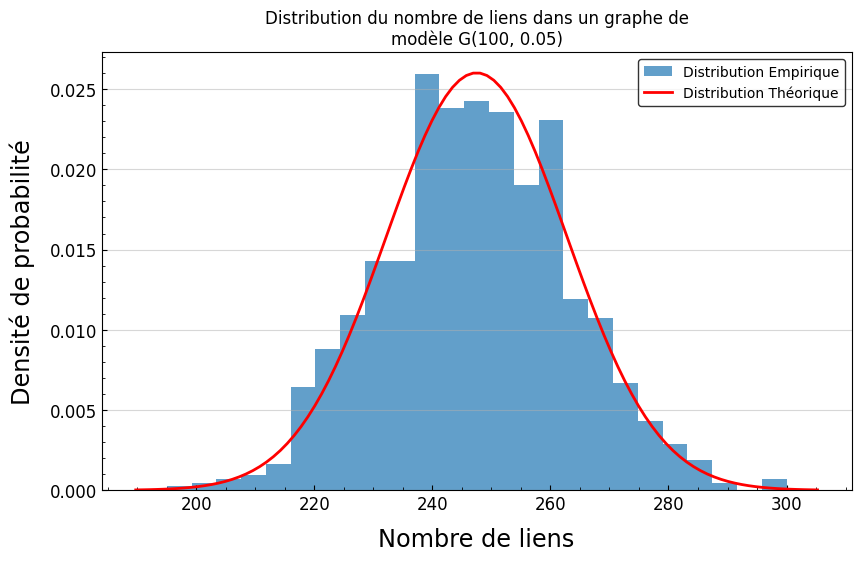

In [31]:
plt.figure(figsize=(10,6))
plt.hist(edges, bins="auto", density=True, alpha=0.7, label="Distribution Empirique") # on affiche la distribution du nombre de liens des 1000 graphes
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
pdf = norm.pdf(x, moy_th, std_th)
plt.plot(x, pdf, "r-", lw=2, label="Distribution Théorique")
plt.title(f"Distribution du nombre de liens dans un graphe de\nmodèle G({n}, {p})")
plt.xlabel("Nombre de liens")
plt.ylabel("Densité de probabilité")
plt.grid(axis="y", alpha=0.5)
plt.legend()
plt.show()

Comme il est possible d'apercevoir sur l'histogramme, la distribution du nombre de liens par graphe suit une loi normale de par l'intervention du théorème central limite. En comparant les résultats empiriques contre les résultats théoriques, il est possible de constater que les formules démontrées en **a** et **b** sont valides puisque les valeurs qu'elles fournissent sont pratiquement identiques aux valeurs théoriques. Ceci confirme donc que l'hypothèse d'un processus binomial étant à l'origine de la génération d'un graphe basé sur le modèle d'Erdos-Rényi était la bonne.

## 4.2 d) Implémentez la simulation de la dynamique SIS sur réseau en utilisant le module ```NetworkX```. Une fois votre algorithme fonctionnel, générez les courbes moyennes du nombre de noeuds infectés et susceptibles en fonction du temps pour le réseau fourni. Pour vos simulations, utilisez $\alpha=0.05$ et $\beta=0.1$, une proportion initiale de noeuds infectés de 10% et 100 pas de temps. Comparez les résultats de la simulation avec la dynamique SIS étudiée dans la première partie du travail et discutez.

In [28]:
import random
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
plt.style.use('https://raw.githubusercontent.com/dccote/Enseignement/master/SRC/dccote-basic.mplstyle')

In [89]:
def SIS(network: nx.Graph, properties: tuple) -> dict:
    """
    Algorithme permettant l'étude du modèle épidémiologique SIS
    sur un réseau quelconque
    
    Arguments :
        network : graphe quelconque sur lequel se déroule la simulation
        
        properties : attributs de la simulation tels que la probabilité de
        guérison, d'infection, la proportion initiale d'infectés et le nombre
        de pas temporels
    
    Returns :
        dict : Un dictionnaire contenant les pas de temps de la simulation ainsi que les comptes de noeuds
        susceptibles et infectés.
    """
    
    alpha, beta, frac, max_time = properties
    G = network
    node_count = nx.number_of_nodes(G)
    
    states = {}             # On enregistre l'état de chaque noeuds par 1 pour infecté ou 
    for node in G.nodes():  # 0 pour susceptible. Ensuite, on initialise le début de l'épidémie
        states[node] = 0    # en considérant tout le monde comme susceptibleà
    
    count_init_inf = max(1, int(frac * node_count))                 # On détermine le nombre de noeuds infectés au début (en s'assurant qu'il y en ait au moins un)
    nodes_init_inf = random.sample(list(G.nodes()), count_init_inf) # On sélectionne des noeuds au hasard qui deviendront les patients zéros. ```list(G.nodes())``` parce
    for node in nodes_init_inf:                                     # que .nodes() retourne un itérateur
        states[node] = 1                                            # L'état de chaque patient zéro est mis à jour dans le dictionnaire
    
    time = []
    sus_count = []
    inf_count = []
    
    for t in range(max_time):
        s_now = sum(1 for state in states.values() if state==0)
        inf_now = node_count - s_now
        time.append(t)                                          # État des lieux avant l'étape de propagation
        sus_count.append(s_now)
        inf_count.append(inf_now)
        
        if inf_now == 0:
            break # Si il n'y a plus de noeuds infectés, l'épidémie est terminée
        
        next_states = states.copy() # On peut se passer de *deepcopy* parce les entiers 0 et 1 ne changeront pas
        for node in G.nodes():
            if states[node] == 1:
                if random.random() < alpha: # Si un noeud est infecté, quelle est la probabilité qu'il guérisse dans ce pas de temps 
                    next_states[node] = 0
                else:                       # Si le noeud ne peut pas guérir, il peut infecter ses voisins
                    for neighbor in G.neighbors(node):
                        if states[neighbor] == 0:       # On regarde parmis tous les voisins du noeud s'il y en a qui sont susceptibles
                            if random.random() < beta:
                                next_states[node] == 1  # C'est possible qu'on ait la situation suivante : I---S---I où un voisin susceptible se fait
                                                        # infecter par deux noeuds en même temps. Puisque l'état d'un noeud est binaire, on n'infecte
                                                        # le voisin qu'une seule fois
        states = next_states                            # Mise à jour du dictionnaire d'état pour le prochain pas de temps
        """
        Il n'est pas nécesaire de vérifier les noeuds qui sont susceptibles au temps t (else if states[node]==0)
        parce qu'ici, les noeuds infectés sont ceux qui contrôlent l'évolution de l'épidémie. Autrement dit,
        l'état d'un noeud susceptible ne change que s'il se fait infecter par un noeud infecté.
        """
    return {"temps": time, "Susceptible": sus_count, "Infectés": inf_count}

def modelStudy(network: nx.Graph, properties: tuple, iter: int) -> tuple:
    """
    Réalise une étude de plusieurs itérations de la simulation SIS sur réseau, 
    compile et affiche les résultats.
    
    Arguments :
        network : graphe quelconque sur lequel se déroule la simulation
        
        properties : attributs de la simulation tels que la probabilité de
        guérison, d'infection, la proportion initiale d'infectés et le nombre
        de pas temporels
    
    Return : 
        None
    """
    
    s_stack = []                             # On enregistre les courbes des paramètres pour chaque itérations
    i_stack = []
    time = [t for t in range(properties[-1])] # properties[-1] correspond au nombre maximal de pas de temps
    for i in range(iter):
        sim = SIS(network=network, properties=properties)
        susceptible = sim.get("Susceptible")
        if len(susceptible) < len(time):
            susceptible = susceptible + [susceptible[-1]] * (len(time)-len(susceptible))
        infecté = sim.get("Infectés")
        if len(infecté) < len(time):
            infecté = infecté + [infecté[-1]] * (len(time)-len(infecté))
        s_stack.append(susceptible)
        i_stack.append(infecté)
    s_arr = np.stack(s_stack)
    i_arr = np.stack(i_stack)       # On fait la moyenne des valeurs de chaque courbe pour chaque pas de temps
    s_mean = np.mean(s_arr, axis=0)
    i_mean = np.mean(i_arr, axis=0)
    return time, s_mean, i_mean

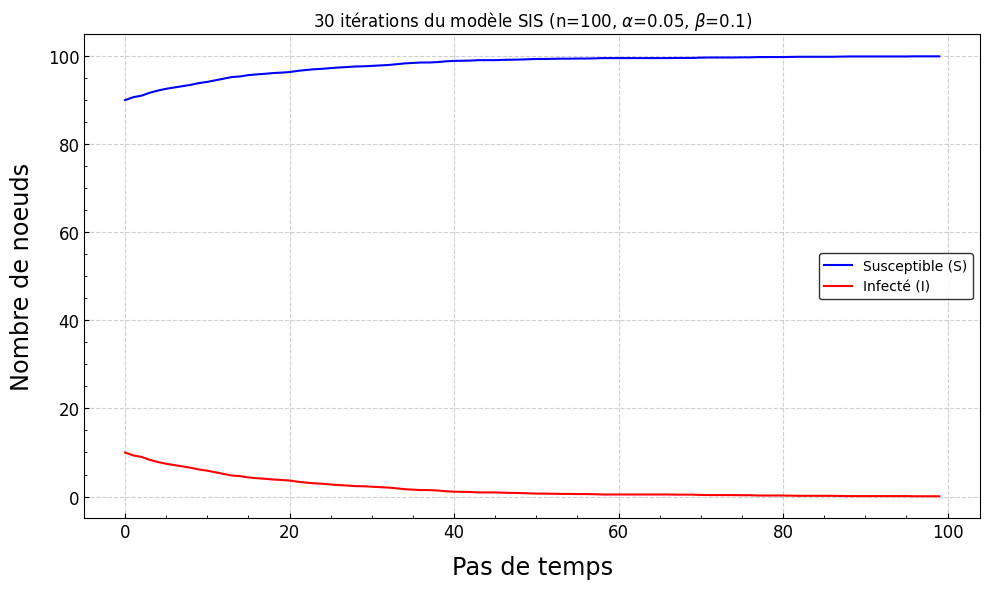

In [95]:
réseau = nx.read_adjlist("reseau.adj")
nombre_noeuds = nx.number_of_nodes(réseau)
iterations = 30
properties = 0.05, 0.1, 0.1, 100
time, s, i = modelStudy(réseau, properties, iterations)
plt.figure(figsize=(10,6))
plt.plot(time, s, label="Susceptible (S)", color="blue")
plt.plot(time, i, label="Infecté (I)", color="red")
plt.xlabel("Pas de temps")
plt.ylabel("Nombre de noeuds")
plt.title(f"{iterations} itérations du modèle SIS (n={nombre_noeuds}, $\\alpha$={0.05}, $\\beta$={0.1})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [77]:
a = [1,2,3,4]
b=[11,12,13]
h = np.block([a,b])
h

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 4 and the array at index 1 has size 3